# 0. 미션 목표 및 기본 설정

이번 미션에서는  모델을 활용하여 FashionMNIST 데이터셋의 각 패션 아이템(예: 티셔츠, 바지, 스니커즈 등)을 조건부로 생성하는 작업을 수행합니다. 

각 클래스에 해당하는 이미지를 생성하는 cGAN (Conditional GAN) 모델을 직접 설계하고 학습시켜 보세요.

In [2]:
!pip -q install torchmetrics[image] torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 65.6 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np
import random
from torch.nn.utils import spectral_norm
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
import torch.nn.functional as F
import math

In [4]:
# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# 시드 고정
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# 1. 데이터셋 설정

In [ ]:
# 데이터셋 및 DataLoader 설정
transform_train = v2.Compose([
    v2.ToImage(),
    v2.RandomHorizontalFlip(p=0.3),
    v2.RandomAffine(degrees=5, translate=(0.03, 0.03), scale=(0.98, 1.02)),
    v2.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02), 
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,))
])

transform_test = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# 클래스 이름 (FashionMNIST 클래스)
idx_to_class = {i: class_name for i, class_name in enumerate(train_dataset.classes)}
idx_to_class

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.22MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 139kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.58MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.2MB/s]


{0: 'T-shirt/top',
 1: 'Trouser',
 2: 'Pullover',
 3: 'Dress',
 4: 'Coat',
 5: 'Sandal',
 6: 'Shirt',
 7: 'Sneaker',
 8: 'Bag',
 9: 'Ankle boot'}

- 데이터 확인 및 클래스별 샘플 시각화

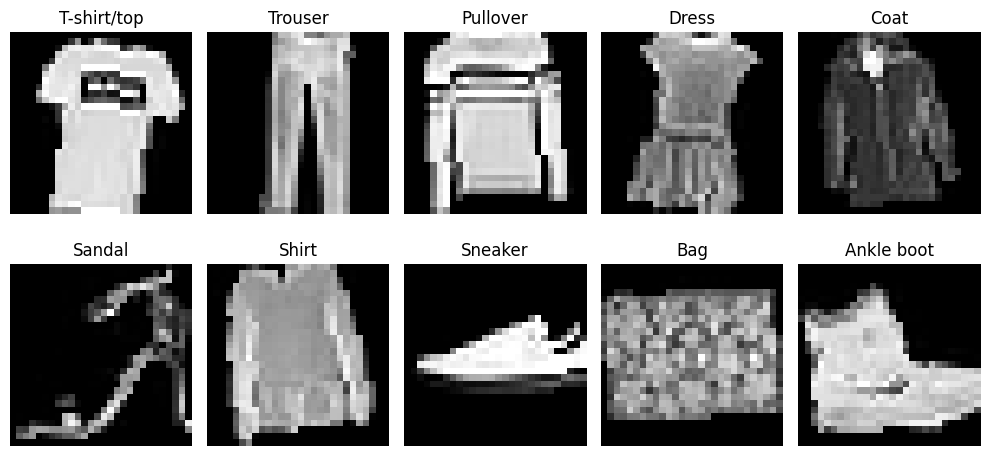

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for cls in range(10):
    img, label = train_dataset[np.where(np.array(train_dataset.targets) == cls)[0][0]]
    axes[cls // 5, cls % 5].imshow(img.squeeze(), cmap='gray')
    axes[cls // 5, cls % 5].set_title(idx_to_class[cls])
    axes[cls // 5, cls % 5].axis('off')
plt.tight_layout()
plt.show()

# 2. Generator, Discriminator 정의

In [ ]:
image_size = 28      # Fashion MNIST 이미지 크기
num_classes = 10     # 10개 클래스  
latent_dim = 128     # 잠재 공간 차원
label_embed_dim = 32 # 레이블 임베딩 차원


# 생성자 (Generator)
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        # 레이블 임베딩
        self.label_emb = nn.Embedding(num_classes, label_embed_dim)

        self.init_size = image_size // 4  # 7

        self.l1 = nn.Sequential(
            nn.Linear(latent_dim + label_embed_dim, 128 * self.init_size * self.init_size),
            nn.ReLU(inplace=True)
        )

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),  # 7 → 14
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64, 0.8),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2),  # 14 → 28
            nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()  # 출력 범위 [-1, 1]
        )

    def forward(self, noise, labels):
        label_input = self.label_emb(labels)
        gen_input = torch.cat((noise, label_input), -1)
        out = self.l1(gen_input)
        out = out.view(out.size(0), 128, self.init_size, self.init_size)
        img = self.conv_blocks(out)
        return img

# 판별자 (Discriminator)
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, image_size * image_size)

        self.model = nn.Sequential(
            spectral_norm(nn.Conv2d(2, 64, 4, 2, 1)),   # 28 -> 14
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),

            spectral_norm(nn.Conv2d(64, 128, 4, 2, 1)), # 14 -> 7
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),

            spectral_norm(nn.Conv2d(128, 256, 3, 1, 1)),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(256 * 7 * 7, 1)
        )

    def forward(self, img, labels):
        label_map = self.label_emb(labels).view(labels.size(0), 1, image_size, image_size)
        d_in = torch.cat([img, label_map], dim=1)
        validity = self.model(d_in)
        return validity

# 3. 학습 및 시각화

In [9]:
# 모델 초기화
generator = Generator().to(device)
discriminator = Discriminator().to(device)

epochs = 30
criterion = nn.BCEWithLogitsLoss()

lr_G = 2e-4
lr_D = 1e-4   

optimizer_G = optim.Adam(generator.parameters(), lr=lr_G, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_D, betas=(0.5, 0.999))

history = {
    "d_loss": [],
    "g_loss": [],
    "d_x": [],
    "d_g_z1": [],
    "d_g_z2": []
}

fixed_noise = torch.randn(num_classes * 3, latent_dim, device=device)
fixed_labels = torch.arange(0, num_classes, device=device).repeat(3)

Epoch [1/30] D_loss: 1.3431 G_loss: 0.8556 D(x): 0.4669 D(G(z)) before G: 0.4385 D(G(z)) after G: 0.4300
Epoch [2/30] D_loss: 1.2958 G_loss: 0.9255 D(x): 0.4836 D(G(z)) before G: 0.4171 D(G(z)) after G: 0.4055
Epoch [3/30] D_loss: 1.3037 G_loss: 0.9173 D(x): 0.4814 D(G(z)) before G: 0.4184 D(G(z)) after G: 0.4096
Epoch [4/30] D_loss: 1.3120 G_loss: 0.9076 D(x): 0.4776 D(G(z)) before G: 0.4215 D(G(z)) after G: 0.4132
Epoch [5/30] D_loss: 1.3167 G_loss: 0.8996 D(x): 0.4754 D(G(z)) before G: 0.4235 D(G(z)) after G: 0.4157
Epoch [6/30] D_loss: 1.3149 G_loss: 0.8987 D(x): 0.4761 D(G(z)) before G: 0.4233 D(G(z)) after G: 0.4149
Epoch [7/30] D_loss: 1.3120 G_loss: 0.9037 D(x): 0.4771 D(G(z)) before G: 0.4224 D(G(z)) after G: 0.4141
Epoch [8/30] D_loss: 1.3102 G_loss: 0.9081 D(x): 0.4780 D(G(z)) before G: 0.4215 D(G(z)) after G: 0.4122
Epoch [9/30] D_loss: 1.3050 G_loss: 0.9119 D(x): 0.4798 D(G(z)) before G: 0.4199 D(G(z)) after G: 0.4111
Epoch [10/30] D_loss: 1.3069 G_loss: 0.9109 D(x): 0.479

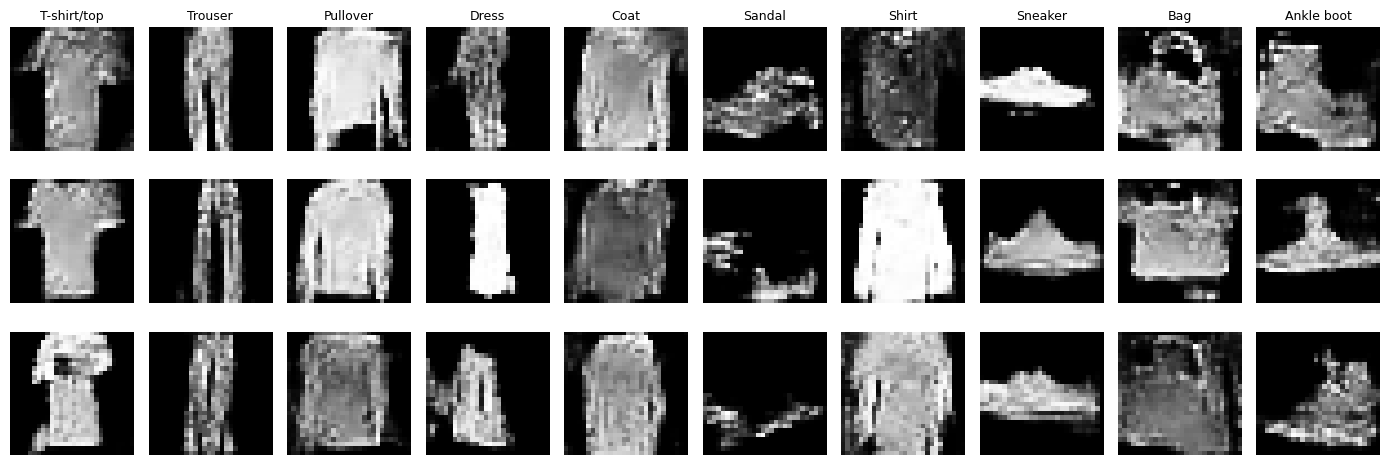

Epoch [11/30] D_loss: 1.3035 G_loss: 0.9132 D(x): 0.4806 D(G(z)) before G: 0.4195 D(G(z)) after G: 0.4113
Epoch [12/30] D_loss: 1.3038 G_loss: 0.9106 D(x): 0.4808 D(G(z)) before G: 0.4193 D(G(z)) after G: 0.4113
Epoch [13/30] D_loss: 1.3015 G_loss: 0.9154 D(x): 0.4816 D(G(z)) before G: 0.4186 D(G(z)) after G: 0.4099
Epoch [14/30] D_loss: 1.2992 G_loss: 0.9187 D(x): 0.4825 D(G(z)) before G: 0.4180 D(G(z)) after G: 0.4096
Epoch [15/30] D_loss: 1.2956 G_loss: 0.9223 D(x): 0.4838 D(G(z)) before G: 0.4164 D(G(z)) after G: 0.4089
Epoch [16/30] D_loss: 1.2908 G_loss: 0.9265 D(x): 0.4857 D(G(z)) before G: 0.4149 D(G(z)) after G: 0.4070
Epoch [17/30] D_loss: 1.2863 G_loss: 0.9365 D(x): 0.4878 D(G(z)) before G: 0.4127 D(G(z)) after G: 0.4039
Epoch [18/30] D_loss: 1.2793 G_loss: 0.9417 D(x): 0.4901 D(G(z)) before G: 0.4102 D(G(z)) after G: 0.4019
Epoch [19/30] D_loss: 1.2755 G_loss: 0.9498 D(x): 0.4919 D(G(z)) before G: 0.4085 D(G(z)) after G: 0.3994
Epoch [20/30] D_loss: 1.2701 G_loss: 0.9563 D(

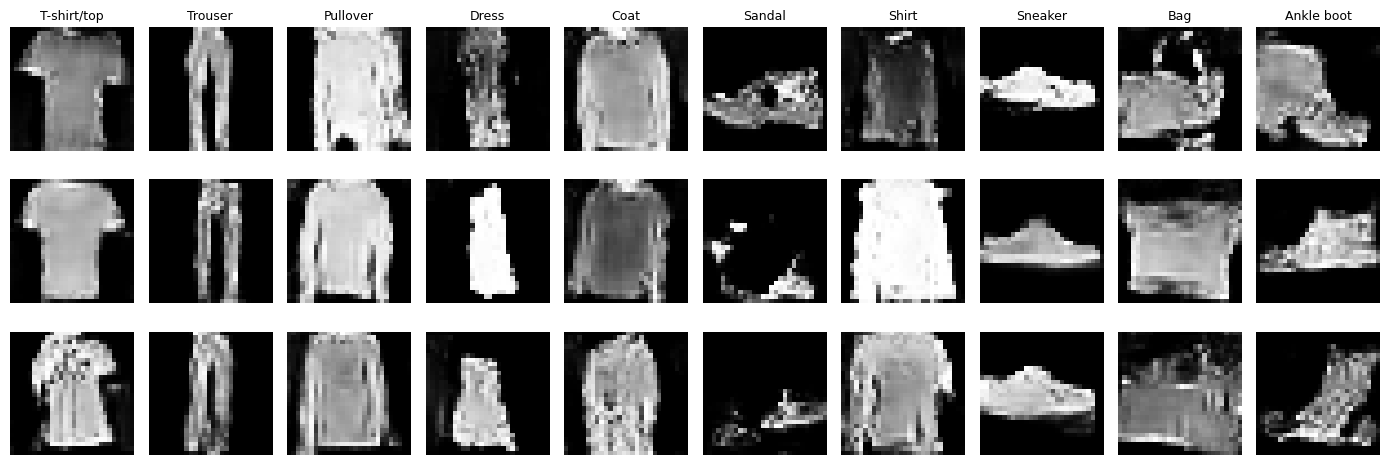

Epoch [21/30] D_loss: 1.2630 G_loss: 0.9645 D(x): 0.4968 D(G(z)) before G: 0.4033 D(G(z)) after G: 0.3950
Epoch [22/30] D_loss: 1.2591 G_loss: 0.9727 D(x): 0.4985 D(G(z)) before G: 0.4017 D(G(z)) after G: 0.3921
Epoch [23/30] D_loss: 1.2538 G_loss: 0.9778 D(x): 0.5008 D(G(z)) before G: 0.3998 D(G(z)) after G: 0.3915
Epoch [24/30] D_loss: 1.2488 G_loss: 0.9886 D(x): 0.5029 D(G(z)) before G: 0.3970 D(G(z)) after G: 0.3883
Epoch [25/30] D_loss: 1.2435 G_loss: 0.9946 D(x): 0.5050 D(G(z)) before G: 0.3953 D(G(z)) after G: 0.3869
Epoch [26/30] D_loss: 1.2417 G_loss: 1.0003 D(x): 0.5062 D(G(z)) before G: 0.3942 D(G(z)) after G: 0.3848
Epoch [27/30] D_loss: 1.2340 G_loss: 1.0057 D(x): 0.5090 D(G(z)) before G: 0.3913 D(G(z)) after G: 0.3826
Epoch [28/30] D_loss: 1.2305 G_loss: 1.0114 D(x): 0.5108 D(G(z)) before G: 0.3892 D(G(z)) after G: 0.3808
Epoch [29/30] D_loss: 1.2270 G_loss: 1.0199 D(x): 0.5124 D(G(z)) before G: 0.3878 D(G(z)) after G: 0.3789
Epoch [30/30] D_loss: 1.2224 G_loss: 1.0285 D(

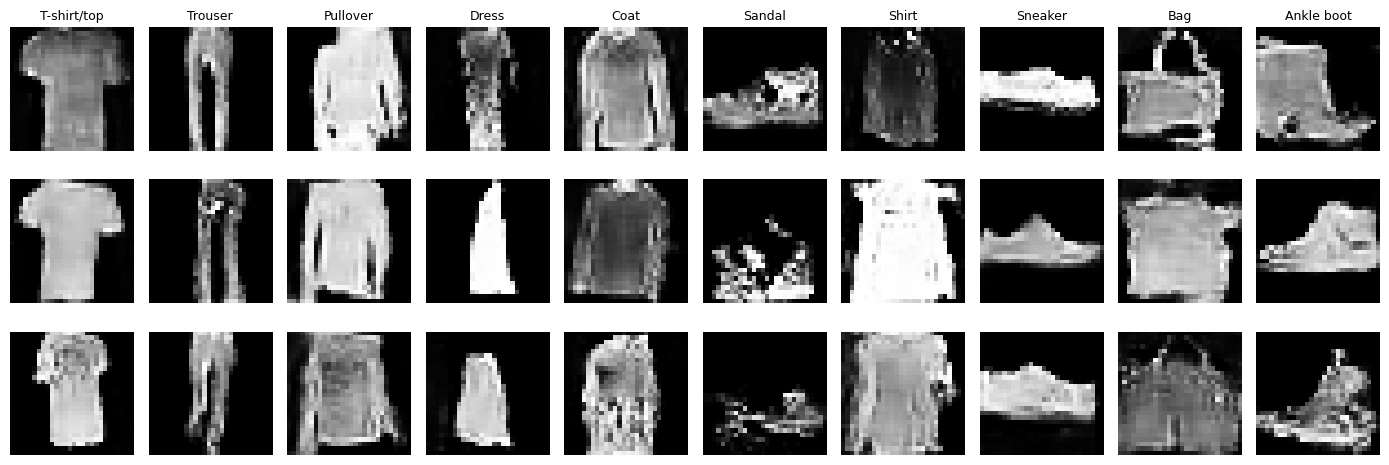

In [ ]:
# 학습 루프
for epoch in range(epochs):
    generator.train()
    discriminator.train()

    epoch_d_loss = 0
    epoch_g_loss = 0
    epoch_d_x = 0
    epoch_d_g_z1 = 0
    epoch_d_g_z2 = 0
    steps = 0

    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        bsz = imgs.size(0)

        real_targets = torch.full((bsz, 1), 0.9, device=device)  
        fake_targets = torch.zeros((bsz, 1), device=device)


        # Discriminator
        
        optimizer_D.zero_grad()

        real_logits = discriminator(imgs, labels)

        noise = torch.randn(bsz, latent_dim, device=device)
        gen_labels = torch.randint(0, num_classes, (bsz,), device=device)
        fake_imgs = generator(noise, gen_labels)

        fake_logits = discriminator(fake_imgs.detach(), gen_labels)

        d_loss_real = criterion(real_logits, real_targets)
        d_loss_fake = criterion(fake_logits, fake_targets)
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()

        d_x = torch.sigmoid(real_logits).mean().item()
        d_g_z1 = torch.sigmoid(fake_logits).mean().item()


        # Generator

        optimizer_G.zero_grad()

        fake_logits_for_g = discriminator(fake_imgs, gen_labels)
        g_loss = criterion(fake_logits_for_g, torch.ones((bsz, 1), device=device))
        g_loss.backward()
        optimizer_G.step()

        with torch.no_grad():
            d_g_z2 = torch.sigmoid(discriminator(fake_imgs, gen_labels)).mean().item()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        epoch_d_x += d_x
        epoch_d_g_z1 += d_g_z1
        epoch_d_g_z2 += d_g_z2
        steps += 1

    history["d_loss"].append(epoch_d_loss / steps)
    history["g_loss"].append(epoch_g_loss / steps)
    history["d_x"].append(epoch_d_x / steps)
    history["d_g_z1"].append(epoch_d_g_z1 / steps)
    history["d_g_z2"].append(epoch_d_g_z2 / steps)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"D_loss: {history['d_loss'][-1]:.4f} "
        f"G_loss: {history['g_loss'][-1]:.4f} "
        f"D(x): {history['d_x'][-1]:.4f} "
        f"D(G(z)) before G: {history['d_g_z1'][-1]:.4f} "
        f"D(G(z)) after G: {history['d_g_z2'][-1]:.4f}"
    )

    if (epoch + 1) % 10 == 0:
        generator.eval()
        with torch.no_grad():
            gen_imgs = generator(fixed_noise, fixed_labels).cpu()

        fig, axs = plt.subplots(3, num_classes, figsize=(14, 5))
        for i in range(3):
            for j in range(num_classes):
                idx = i * num_classes + j
                axs[i, j].imshow(gen_imgs[idx, 0], cmap='gray')
                axs[i, j].axis('off')
                if i == 0:
                    axs[i, j].set_title(idx_to_class[j], fontsize=9)
        plt.tight_layout()
        plt.show()

# 4. 학습 과정 분석

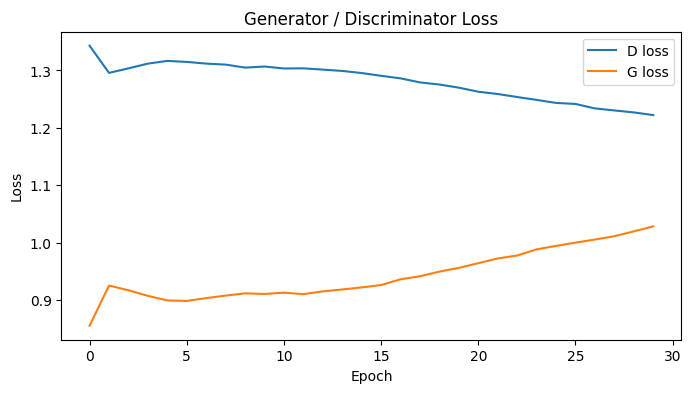

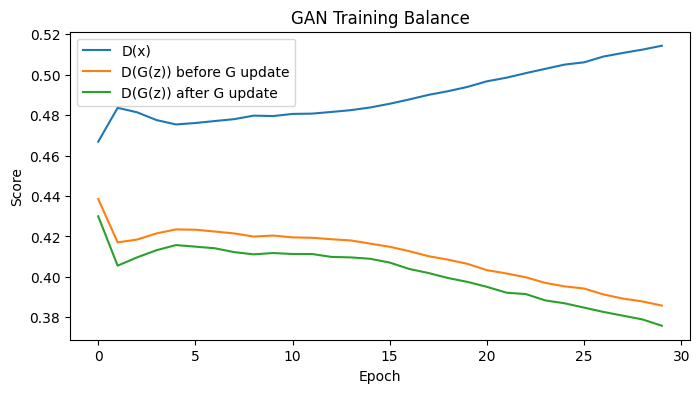

In [ ]:
# 시각화

plt.figure(figsize=(8, 4))
plt.plot(history["d_loss"], label="D loss")
plt.plot(history["g_loss"], label="G loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Generator / Discriminator Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history["d_x"], label="D(x)")
plt.plot(history["d_g_z1"], label="D(G(z)) before G update")
plt.plot(history["d_g_z2"], label="D(G(z)) after G update")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("GAN Training Balance")
plt.legend()
plt.show()

Discriminator loss는 약 1.34에서 1.22로 완만하게 감소하였으며, Generator loss는 약 0.86에서 1.03으로 증가하였다.

Generator가 점점 더 복잡한 이미지를 생성하면서 Discriminator가 구별하기 어려워지는 과정으로 해석할 수 있으며, 학습이 안정적으로 진행되고 있음을 의미한다.

또한 GAN 학습 균형 그래프에서 D(x)는 약 0.47에서 0.51로 유지되었고, D(G(z))는 약 0.43에서 0.38 수준으로 유지되었다.

Discriminator가 실제 이미지와 생성 이미지를 완벽히 구분하지 못하는 균형 상태에 가까워지고 있음을 의미하며,

Generator와 Discriminator가 적절한 경쟁 관계를 유지하며 학습이 진행된 것으로 판단된다.

# 5. 정량 평가 FID / IS

In [ ]:
# Inception Score와 FID 계산을 위한 이미지 전처리 함수
def to_uint8_inception_input(x):
    x = (x + 1) / 2                      # [-1,1] -> [0,1]
    x = x.clamp(0, 1)
    x = x.repeat(1, 3, 1, 1)            # 1채널 -> 3채널
    x = F.interpolate(x, size=(299, 299), mode="bilinear", align_corners=False)
    x = (x * 255).to(torch.uint8)
    return x

# FID
fid = FrechetInceptionDistance(feature=2048).to(device)

# real images update
real_count = 0
target_num = 5000 

for real_imgs, _ in train_loader:
    real_imgs = real_imgs.to(device)
    real_imgs = to_uint8_inception_input(real_imgs)
    fid.update(real_imgs, real=True)
    real_count += real_imgs.size(0)
    if real_count >= target_num:
        break

# fake images update
generator.eval()
fake_count = 0
batch_size_eval = 128

with torch.no_grad():
    while fake_count < target_num:
        cur_bsz = min(batch_size_eval, target_num - fake_count)
        z = torch.randn(cur_bsz, latent_dim, device=device)
        labels = torch.randint(0, num_classes, (cur_bsz,), device=device)
        fake_imgs = generator(z, labels)
        fake_imgs = to_uint8_inception_input(fake_imgs)
        fid.update(fake_imgs, real=False)
        fake_count += cur_bsz

fid_score = fid.compute().item()

# IS
inception_score = InceptionScore().to(device)

generator.eval()
target_num = 5000
done = 0
batch_size_eval = 128

with torch.no_grad():
    while done < target_num:
        cur_bsz = min(batch_size_eval, target_num - done)
        z = torch.randn(cur_bsz, latent_dim, device=device)
        labels = torch.randint(0, num_classes, (cur_bsz,), device=device)
        fake_imgs = generator(z, labels)
        fake_imgs = to_uint8_inception_input(fake_imgs)
        inception_score.update(fake_imgs)
        done += cur_bsz

is_mean, is_std = inception_score.compute()


In [ ]:
print(f"FID: {fid_score:.4f}")
print(f"Inception Score: {is_mean.item():.4f} ± {is_std.item():.4f}")

FID: 34.0535
Inception Score: 3.9947 ± 0.0994


정량 평가 결과는

- **FID:** 34.05
- **Inception Score:** 3.99 ± 0.10

FID는 생성 이미지 분포와 실제 데이터 분포 간의 차이를 측정하는 지표로,
값이 낮을수록 생성 이미지가 실제 데이터와 유사함을 의미한다.

Inception Score는 생성 이미지의 품질과 다양성을 동시에 평가하는 지표로,
값이 높을수록 더 명확하고 다양한 이미지를 생성함을 의미한다.

FashionMNIST 데이터셋 기준으로
FID 20~40, IS 3.5~4.5 범위는 비교적 좋은 생성 품질로 해석된다.

FashionMNIST의 각 클래스 특징을 비교적 잘 학습하여 안정적인 이미지 생성을 수행한 것으로 판단된다.